# Wykład #3

## 1. Próby bootstrapowe

Chociaż ta sekcja nie nawiązuje bezpośrednio do zagadnienia wstępnego przetwarzania danych, to jest nawiązaniem do poprzedniego wykładu i części związanej z rozkładami danych, populacją oraz próbami z rozkładów.

**Czym są próby bootstrapowe?**

Próby bootstrapowe służą do tego samego - stworzenia zbioru (najczęściej wielu zbiorów) danych, prób z populacji. Jednak technika ta polega na wielokrotnym losowaniu ze zwracaniem ze zbioru bazowego (populacji), aby oszacować niepewność statystyk (np. średniej, mediany, dokładności modelu).

**Najważniejsza idea:**

> Zamiast zbierać nowe dane, **symulujemy nowe próbki poprzez losowanie z powtórzeniami** z istniejącego zbioru.

**Intuicja**

Załóżmy, że masz dane:

```
[2, 4, 5, 7, 9]
```

Bootstrap tworzy nowe próbki tej samej wielkości, ale losujemy **z powtórzeniami**.

Przykładowe próbki bootstrapowe:

```
[4, 4, 9, 2, 7]
[5, 2, 2, 9, 9]
[7, 5, 4, 4, 2]
```

Każda próbka:

* ma tyle samo elementów,
* ale niektóre wartości się powtarzają,
* inne mogą nie wystąpić.


**Po co używa się bootstrapu?**

Bootstrap pozwala oszacować:

* błąd standardowy
* przedziały ufności
* stabilność modelu ML
* wariancję statystyk

Bez skomplikowanych wzorów matematycznych.

Dlatego bootstrap jest bardzo popularny data science oraz machine learning.

---

**Algorytm bootstrap**

1. Mamy zbiór danych o rozmiarze **n**
2. Losujemy próbkę wielkości **n** z powtórzeniami
3. Liczymy interesującą statystykę (np. średnią)
4. Powtarzamy to np. **1000 razy**
5. Analizujemy rozkład wyników

### Przykład 1 — bootstrap średniej

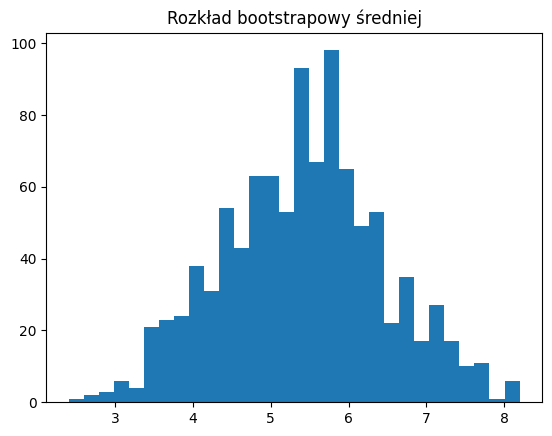

In [7]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([2, 4, 5, 7, 9])

# generowanie próbek bootstrapowych
n_bootstrap = 1000
means = []

for _ in range(n_bootstrap):
    sample = np.random.choice(data, size=len(data), replace=True)
    means.append(np.mean(sample))

means = np.array(means)

# wizualizacja
plt.hist(means, bins=30, )
plt.title("Rozkład bootstrapowy średniej")
plt.show()

To co widzimy to rozkład możliwych wartości średniej.

### Przykład 2 — przedział ufności z prób bootstrapowych

Bootstrap świetnie nadaje się do estymacji przedziałów ufności.

In [9]:
# to daje 95% przedział ufności (środkowe 95% danych z rozkładu)
lower = np.percentile(means, 2.5)
upper = np.percentile(means, 97.5)

print(lower, upper)

# i dla mediany
medians = []

for _ in range(1000):
    sample = np.random.choice(data, len(data), replace=True)
    medians.append(np.median(sample))

np.percentile(medians, [2.5, 97.5])

3.4 7.4


array([2., 9.])

### Przykład 4 — bootstrap w Machine Learning

Ocena stabilności modelu.

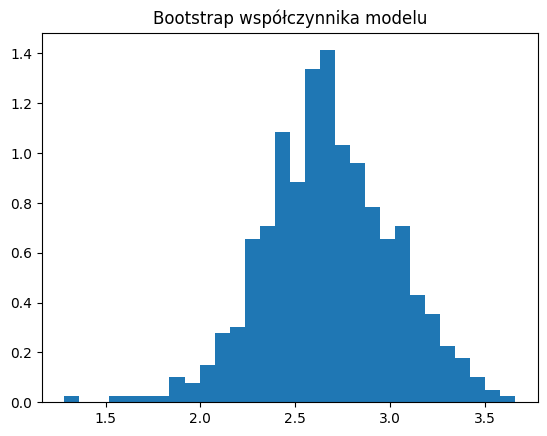

In [11]:
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression

X = np.random.rand(100,1)
y = 3*X.squeeze() + np.random.randn(100)

# współczynnik modelu (tu regresji)
coefs = []

for _ in range(500):
    X_sample, y_sample = resample(X, y)
    model = LinearRegression().fit(X_sample, y_sample)
    coefs.append(model.coef_[0])

plt.hist(coefs, bins=30, density=True)
plt.title("Bootstrap współczynnika modelu")
plt.show()

Pokazuje to jak bardzo zmienia się parametr modelu.

### Próby boostrapowe - podsumowanie.

Bootstrap wykorzystuje ideę:

> próbka jest przybliżeniem populacji.

Losując z niej wiele razy, symulujemy proces pobierania wielu próbek z populacji.


**Zalety bootstrapu:**

* nie wymaga założeń o rozkładzie danych
* działa dla małych próbek
* łatwy do implementacji
* uniwersalny
* redukcja wariancji:
  * uśrednianie wyników z wielu modeli zmniejsza ryzyko, że ostateczny model będzie zbyt wrażliwy na specyficzne dane treningowe
* lepsza generalizacja:
  * zapobiega overfittingowi, zwłaszcza w przypadku modeli o wysokiej wariancji (np. głębokie drzewa decyzyjne).

**Ograniczenia:**

* nie działa dobrze dla silnie zależnych obserwacji (np. szeregi czasowe bez modyfikacji)

Bootstrap odpowiada na pytanie:

> *Jak bardzo wynik zmieniłby się, gdybyśmy ponownie zebrali dane?*

— bez ponownego zbierania danych.

---

Popularne modele ML, które wykorzystują bootstrapping:

1. **Bagging (Bootstrap Aggregating)**

**Bagging** to technika, która trenuje wiele modeli tego samego typu na różnych, bootstrapowych próbkach danych, a następnie agreguje ich wyniki (przez głosowanie większościowe dla klasyfikacji lub uśrednianie dla regresji). 

* Random Forest (Las Losowy)
* Bagged Decision Trees

2. **Algorytmy z rodziny Boosting (pochodne):**
* AdaBoost
* Stochastic Gradient Boosting (podobne rozwiązanie do bootstrapu, podpróbki danych). 

3. **Metody Statystyczne i Walidacyjne**

* **Bootstrap Validation**: Używany do oceny stabilności modelu. Próbki bootstrapowe (o rozmiarze oryginalnych danych) tworzą zbiory treningowe, a obserwacje nie wylosowane do danej próbki (tzw. out-of-bag samples) służą jako zbiór testowy.

4. **Uczenie ze wzmacnianiem (Reinforcement Learning):**

Algorytmy oparte na różnicy czasowej (TD learning): Algorytmy takie jak **Q-learning** czy **SARSA** korzystają z "bootstrappingu" w sensie aktualizacji wartości stanu na podstawie szacowanej wartości następnego stanu, a nie pełnego zwrotu. 



## 2. Korelacja cech

Korelacja jest metryką standardową (jej wartości mieszczą się w przedziale od -1 do 1), która wskazuje stopień zależności wartości dwóch zmiennych. Jeżeli wartość jednej z badanych cech rośnie i wartość drugiej cechy również rośnie, mówimy o pozytywnej/dodatniej korelacji, której stopień określamy badając wartość tej metryki. W przypadku odwrotnym (wartość obu cech maleje) mówimy o korelacji negatywnej/ujemnej korelacji.

Korelacja o wartości 0 mówi nam, że cechy nie są skorelowane, a wartości równe ekstremom tej metryki mówią o idealnej korelacji, która może oznaczać silną zależność liniową cech.

Korelacja w data science pozwala nam określić, które predykatory są skorelowane ze sobą, ale również które predykatory są skorelowane ze zmienną decyzyjną. Odnalezienie takich cech w zbiorze danych pozwala na podjęcie kroków, które mogą polegać chociażby na redukcji wymiarowości abioru danych poprzez redukcję cech lub inne techniki inżynierii cech (ang. feature engineering).

Z racji tego, że nie jest to wartośc binarna - jest korelacja, nie ma korelacji - a ciągła w przedziale, to często przyjmuje się poniższy podział aby tę korelację stopniować w bardziej "ludzkiej" skali (dotyczy to oczywiście również korelacji negatywnej)
:
* wartość korelacji 0,0 – 0,3: Brak lub bardzo słaba korelacja,
* wartość korelacji 0,3 – 0,5: Korelacja słaba lub umiarkowana,
* wartość korelacji 0,5 – 0,7: Korelacja umiarkowana lub silna,
* wartość korelacji 0,7 – 0,9: Korelacja silna lub wysoka,
* wartość korelacji 0,9 – 1,0: Korelacja bardzo silna.

**Korelacja Pearsona**

Jest to najpowszechniej stosowana metoda obliczania korelacji dwóch zmiennych. Jej wzór przedstawia się następująco.

$$ \huge r = \frac {\sum_{i=1}^n(x_i - \bar{x})(y_i - \bar{y})}{(n - 1)s_xs_y} $$

gdzie

$(x_i - \bar{x})$ - odchylenie od średniej dla pierwszej cechy

$(y_i - \bar{y})$ - odchylenie od średniej dla drugiej cechy

$s_xs_y$ - iloczyn odchyleń standardowych obu zmiennych

Warto zaznaczyć, że jest to **metoda działająca dla danych numerycznych nieporządkowych**. Działa dobrze dla **danych skorelowanych liniowo**, może nie wskazywać miarodajnych wartości dla innych typów zależności oraz dla **wartości odstających**. Dane, dla których ją stosujemy powinny mieć rozkład normalny.

Z ostatnimi dwoma problemami można sobie radzić poprzez logarytmizację zmiennych.
To jeden z przypadków, który pokazuje, że kolejność przekształceń danych ma często decydujące znaczenie, nawet jeśli na pierwszy rzut oka może wydawać się inaczej.

**Przykład 1**

In [29]:
# policzymy korelację Pearsona "na piechotę"
x = [1, 5, -2]
y = [2, 0, 3]

# najpierw średnie dla obu cech
mean_x = sum(x) / len(x)
mean_y = sum(y) / len(y)

# teraz odchylenia dla obu zmiennych
dev_x = [val - mean_x for val in x]
dev_y = [val - mean_y for val in y]

# odchylenia standardowe dla obu cech
import statistics

std_x = statistics.stdev(x)
std_y = statistics.stdev(y)

# to teraz cały licznik
licznik = sum([dev_x[idx] * dev_y[idx] for idx in range(len(x))])

# i mianownik
mianownik = (len(x) - 1) * std_x * std_y

# i wreszcie wartość korelacji
r = licznik / mianownik

# korelacja wynosi
r

-0.9941916256019201

**Przykład 2**

In [32]:
# teraz z wykorzystaniem zaimplementowanych metod
print(statistics.correlation.__doc__)
print('-' * 50)

# korelacja Pearsona
print(statistics.correlation(x,y))

Pearson's correlation coefficient

Return the Pearson's correlation coefficient for two inputs. Pearson's
correlation coefficient *r* takes values between -1 and +1. It measures
the strength and direction of a linear relationship.

>>> x = [1, 2, 3, 4, 5, 6, 7, 8, 9]
>>> y = [9, 8, 7, 6, 5, 4, 3, 2, 1]
>>> correlation(x, x)
1.0
>>> correlation(x, y)
-1.0

If *method* is "ranked", computes Spearman's rank correlation coefficient
for two inputs.  The data is replaced by ranks.  Ties are averaged
so that equal values receive the same rank.  The resulting coefficient
measures the strength of a monotonic relationship.

Spearman's rank correlation coefficient is appropriate for ordinal
data or for continuous data that doesn't meet the linear proportion
requirement for Pearson's correlation coefficient.

--------------------------------------------------
-0.9941916256019199


Wygląda na to, że nasze wyliczenia ręczne są poprawne.

In [38]:
# pakiet numpy
import numpy as np

# macierz korelacji
np.corrcoef(x,y)

array([[ 1.        , -0.99419163],
       [-0.99419163,  1.        ]])

### Wizualizacja korelacji

Wartość korelacji jest oczywiście kluczowa w podjęciu ewentualnych dalszych kroków przetwarzania zbioru danych. Jednak człowiek jako istota bazująca głównie na zmyśle wzroku potrafi szybko dokonać analizy tego co widzi. To pozwala szybko odnaleźć cechy, które mogą wykazywać wysoką korelację.

<Axes: >

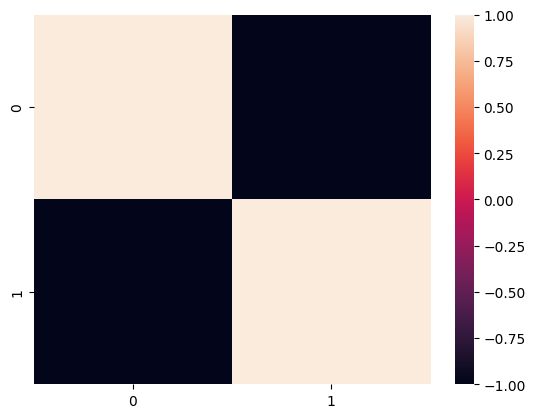

In [42]:
# w seaborn (ale nie tylko) mamy typ wykresów nazywany mapami ciepła (ang. heat map), który
# idealnie nadaje się do przedstawiania wartości ustandaryzowanych
import seaborn as sns
sns.heatmap(np.corrcoef(x,y), vmin=-1, vmax=1)

Nie jest to na pewno wykres, który dla tak małego zbioru danych jest potrzebny i informatywny.

Sprawdźmy więc jego działanie na zbiorze nieco większym.


In [52]:
from sklearn.datasets import load_iris
import pandas as pd

# lub do ramki pandas
data = load_iris(as_frame=True)
df_iris = data.frame
df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [62]:
df_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


**A czy ten zbiór danych wykazuje cechy rozkładu normalnego?**

<Axes: ylabel='Density'>

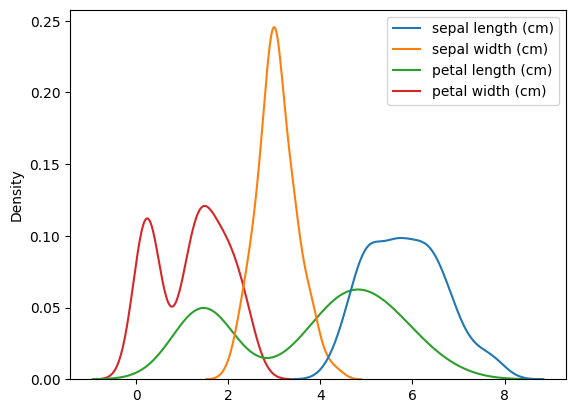

In [118]:
# rozkład wartości cech
sns.kdeplot(df_iris.iloc[:, :-1])

Cechy `sepal width` oraz `sepal length` wykazują cechy rozkładu normalnego, ale pozostałe dwie już nie.

In [119]:
# print(pd.DataFrame.kurtosis.__doc__)
data.data.kurtosis()

sepal length (cm)   -0.552064
sepal width (cm)     0.228249
petal length (cm)   -1.402103
petal width (cm)    -1.340604
dtype: float64

Widać również po wartości kurtozy, że korelacja Pearsona może nie być najlepszym podejściem do wyszukania zależności cech w tym zbiorze. Policzymy ją jednak i następnie porównamy z innymi, wyliczonymi wartościami korelacji.

In [120]:
# macierz korelacji Pearsona
# uwaga, numpy domyślnie traktuje WIERSZE jako wektory wartości dla jednej cechy
# nasz układ jest kolumnowy!!!
corr_mat = np.corrcoef(df_iris.iloc[:, :-1], rowvar=False)
corr_mat

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

In [77]:
# można to również wykonać w samym pandasie
# co jest znacznie czytelniejsze
df_iris.corr()

# warto jednak zaznaczyć, że w przypadku tego zbioru korelacja dla cechy target jest kompletnie
# pozbawiona sensu, wartość w tej kolumnie charakterysuje typ irysa, ale w postaci numerycznej
# korelacja dla parametru decyzjnego ma zazwyczaj sens dla 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


In [79]:
corr_mat_pd = df_iris.iloc[:, :-1].corr()
corr_mat_pd

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


<Axes: >

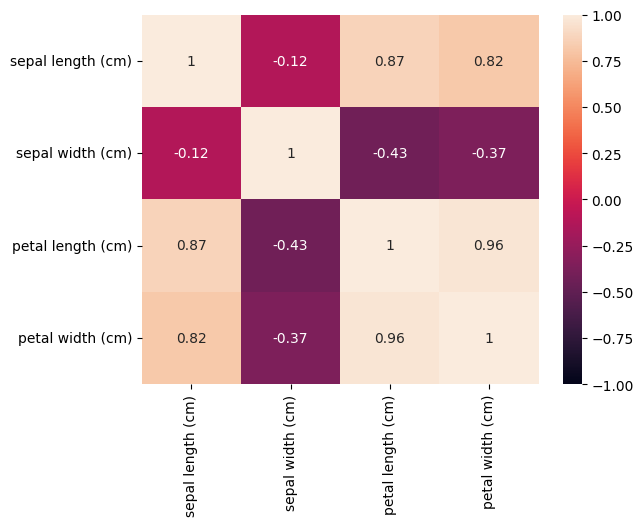

In [80]:
# i mapa cieplna
sns.heatmap(corr_mat_pd, vmin=-1, vmax=1, annot=True, xticklabels=True, yticklabels=True)

Na podstawie takiego wykresu możemy wyciągnąć już dość szybko pewne wnioski:
* cecha `petal length` jest wysoce dodatnio skorelowana z cechą `sepal length` oraz `petal width` (i vice versa oczywiście, stąd w nazwie mamy co-relation)
* cecha `sepal widt` jest umiarkowanie skorelowana negatywnie z cechami `petal length` oraz `petal_width`
* najniższą korelację wykazują cechy `sepal width` oraz `sepal length`

Innym, popularnym wykresem do wizualizacji korelacji jest wykres punktowy (ang. scatter plot). Poniżej przykład jego zastosowania.

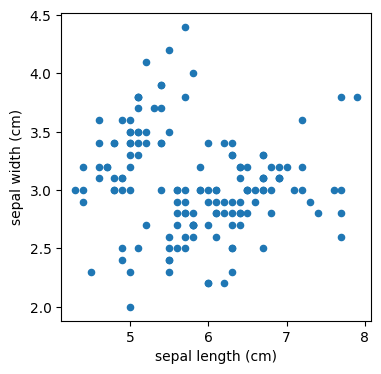

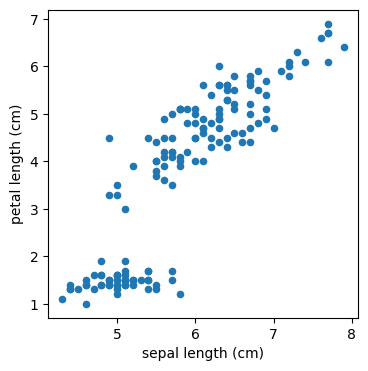

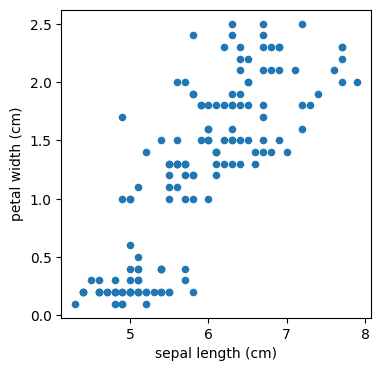

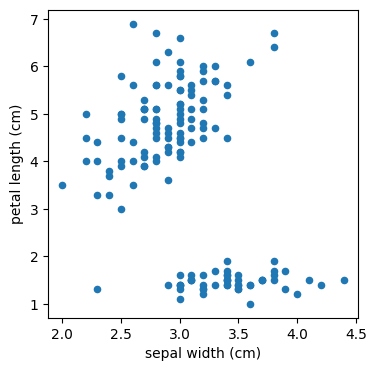

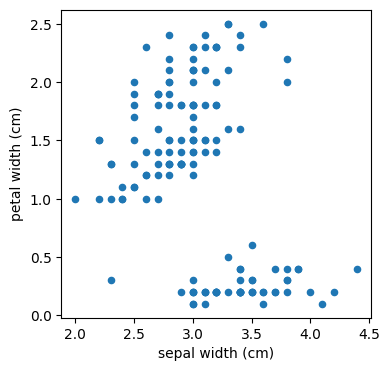

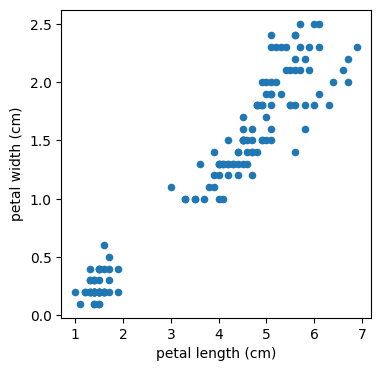

In [104]:
# kombinacje cech dla ramki
import itertools

pairs = list(itertools.combinations(df_iris.columns[:-1], 2))
# fig, ax = plt.subplots(2,3)

for idx, pair in enumerate(pairs):
    df_iris.plot.scatter(pair[0], pair[1], figsize=(4,4))
    

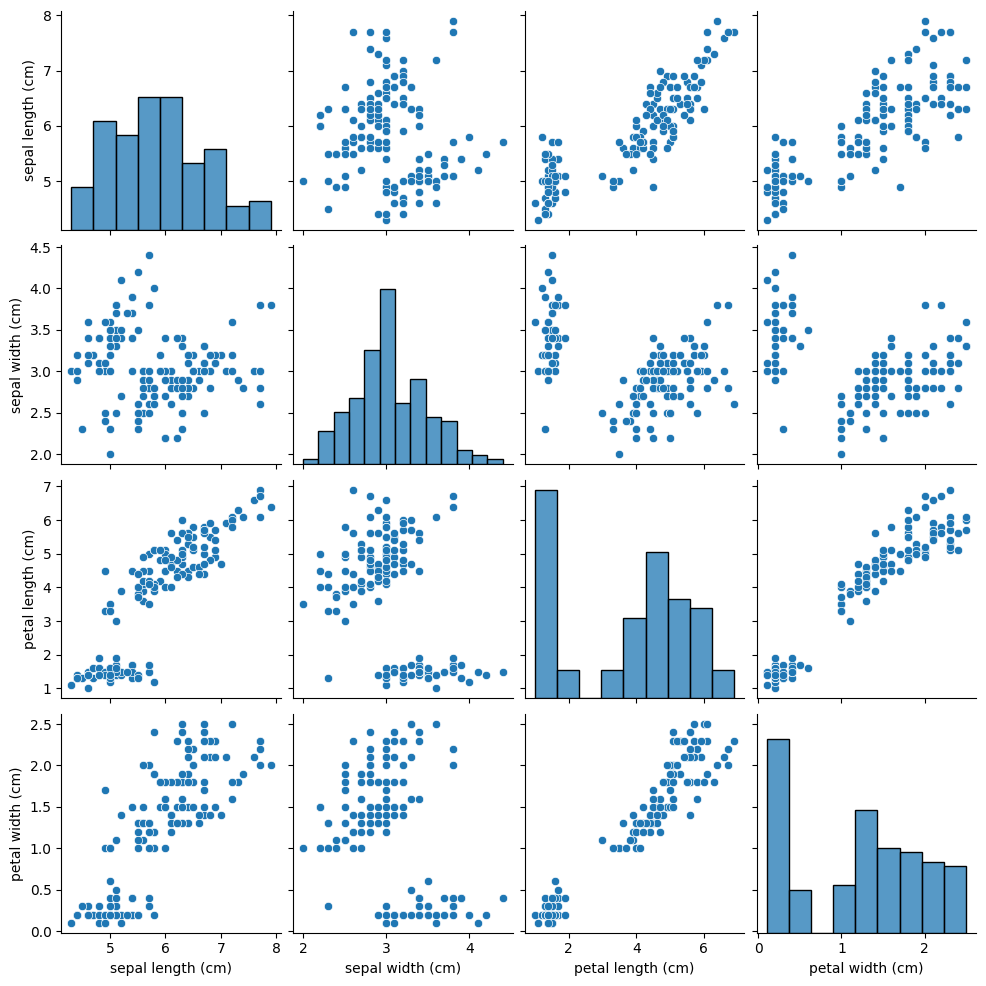

In [110]:
# z seaborn jest to nieco zgrabniejsze z podwykresami, ale tylko dla niewielkiej ilości cech
# tutaj pairplot sprawdzi się idealnie
sns.pairplot(df_iris.iloc[:, :-1])

#### **Korelacja Spearmana**

Korelacja Spearmana (współczynnik 
 Spearmana, nazywany również `rho` Spearmana) to nieparametryczna miara monotonicznej zależności między dwiema zmiennymi, oparta na ich rangach, a nie wartościach surowych. Stosowana jest dla danych porządkowych, ilościowych bez rozkładu normalnego lub przy obecności obserwacji odstających. 
 
**Kluczowe informacje o korelacji Spearmana:**
* Gdy dane są na skali porządkowej (rankingi, oceny) lub ilościowej, ale nie spełniają założeń normalności rozkładu (dla testu Pearsona).
* Jest bardziej odporna na obserwacje odstające, ponieważ analizuje rangi (pozycje w uporządkowanym zbiorze), a nie surowe wartości.
* Mierzy, czy wzrostowi jednej zmiennej towarzyszy wzrost lub spadek drugiej, nawet jeśli nie jest to zależność liniowa.

**Wzór ogólny zaproponowany przez Spearmana**

$$ \huge r_s = corr(RX, RY)$$

gdzie:

$corr$ - klasyczny współczynnik korelacji,

$RX$ - rangi zmiennej $X$ w próbie,

$RY$ - rangi zmiennej $Y$ w próbie.


**Inny wzór (dla rang niewiązanych)***

$$ \huge r_s = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

gdzie

$d_i$ - różnica  między rangami

$n$ to liczba par obserwacji.

\* Ranga niewiązana (niepołączona), czyli wartości nie powtarzają się w obrębie próby dla żadnej ze zmiennych z osobna.

Korelację Spearmana warto wybierać, gdy badamy np. zależność między rangą w konkursie a czasem przygotowania, lub gdy dane są nieliczne i rozproszone. 



In [123]:
# korelacja Spearmana, dla porównania
print(statistics.correlation(df_iris['petal length (cm)'], df_iris['petal width (cm)'], method='ranked'))
statistics.correlation(df_iris['sepal length (cm)'], df_iris['sepal width (cm)'], method='ranked')

0.9376668235763413


-0.166777658283235

<Axes: >

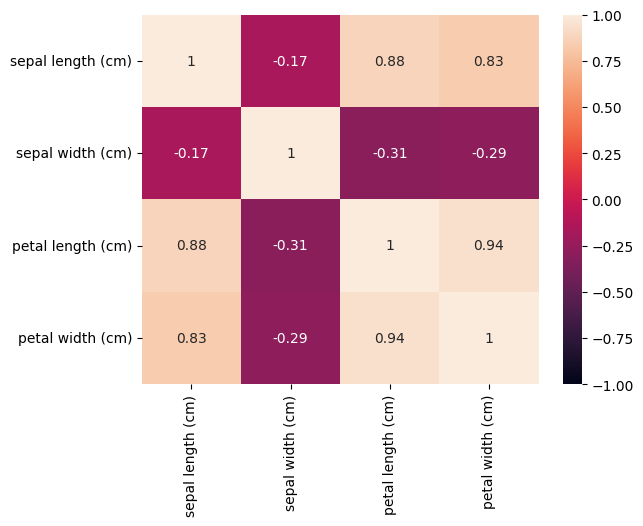

In [130]:
from scipy.stats import spearmanr

sns.heatmap(spearmanr(df_iris.iloc[:, :-1]).statistic, vmin=-1, vmax=1, annot=True, xticklabels=df_iris.columns[:-1], yticklabels=df_iris.columns[:-1])

Wyniki są dość zbliżone dla obu metryk, ale różnica dla cech, które nie wykazują cech rozkładu normalnego jest większa.

### Korelacja tau Kendalla

**Korelacja Kendalla (τ – tau)** to miara statystyczna opisująca **siłę i kierunek zależności między dwiema zmiennymi**, oparta na **porównywaniu rang obserwacji**.

W przeciwieństwie do klasycznej korelacji liniowej Pearsona korelacja Kendalla **nie zakłada liniowości ani normalnego rozkładu danych**. Dlatego jest często używana w analizie danych z **rangami lub danymi porządkowymi**.

**Intuicaj działania**


Korelacja Kendalla analizuje **wszystkie pary obserwacji** i sprawdza, czy ich kolejność jest zgodna.

Dla dwóch obserwacji:

$(x_i, y_i), (x_j, y_j)$


sprawdzamy czy:

* para jest zgodna zgodna (ang. concordant) jeśli $x_i < x_j \quad i \quad y_i < y_j$ lub $x_i > x_j \quad i \quad y_i > y_j$ czyli **obie zmienne rosną lub maleją razem**.
* para jest niezgodna (ang. discordant) jeśli $x_i < x_j \quad ale \quad y_i > y_j$ czyli **jedna zmienna rośnie, a druga maleje**.

**Wzór**

Korelacja Kendalla:

$$ \huge \tau = \frac{C - D}{C + D}$$

gdzie:

* $C$ – liczba par zgodnych
* $D$ – liczba par niezgodnych

Wartości:

| τ  | interpretacja              |
| -- | -------------------------- |
| 1  | idealna korelacja dodatnia |
| 0  | brak zależności            |
| -1 | idealna korelacja ujemna   |

**Przykład w Pythonie z wykorzystaniem biblioteki `scipy`.**

In [3]:
from scipy.stats import kendalltau

x = [1, 2, 3, 4, 5]
y = [2, 3, 5, 6, 7]

tau, p_value = kendalltau(x, y)

print("Tau:", tau)
print("p-value:", p_value)

Tau: 0.9999999999999999
p-value: 0.016666666666666666


Interpretacja:

* **tau** – siła korelacji
* **p-value** – czy korelacja jest statystycznie istotna.

Należy jednak wcześniej ustalić jaka jest hipoteza zerowa, która dla tej funkcji brzmii tak (za dokumentacją `scipy.kendalltau`):
> ... The p-value for a hypothesis test whose null hypothesis is an absence of association, tau = 0.

To oznacza, że z dużą pewnością możemy stwierdzić, że wyliczona wysoka korelacja nie jest dziełem przypadku (lub jest dziełem przypadku w niewielkim stopniu, równym p).

**Kolejny przykład**

In [5]:
x = [1,2,3,4,5]
y = [5,6,7,8,7]

tau, p = kendalltau(x,y)

print(tau, p)

0.7378647873726218 0.07697417298126674


**Przykładowy scenariusz wykorzystanie korelacji Kendalla**

Załóżmy dane:

* ranking restauracji przez klientów
* ranking przez krytyków

Chcemy sprawdzić czy są zgodne.

Interpretacja:

* wysoka wartość oznacza, że rankingi są podobne.

In [9]:
from scipy.stats import kendalltau

customers = [1,2,3,4,5]
critics = [2,1,3,5,4]

kendalltau(customers, critics)

SignificanceResult(statistic=np.float64(0.6), pvalue=np.float64(0.23333333333333334))

**Kiedy używać korelacji Kendalla**

Najlepiej sprawdza się gdy:

* dane są **porządkowe (rankingi)**
* mamy **mało obserwacji**
* występują **outliery**
* zależność nie jest liniowa

### Korelacja - podsumowanie

**Korelacja Pearsona**

* mierzy **zależność liniową**
* wrażliwa na outliery
* wymaga danych numerycznych.


**Korelacja Spearmana**

* opiera się na **rangach**
* szybsza do obliczenia


**Korelacja Kendalla**

* opiera się na parach obserwacji
* dobra dla **małych próbek**
* odporna na outliery

## Wykorzystanie korelacji

Oprócz informacji o **powiązaniu dwóch lub więcej zmiennych ze sobą** (np. korelacja wydatki na reklamę -> przychody, ilość czasu poświęconego na naukę -> oceny, notowania surowca -> notowania spółki, itp.) można również wykorzystać korelację do celów bliżej związanych z procesem wstępnego przetwarzania danych. Głównym jej zastosowaniem jest poszukiwanie odpowiedzi na pytania dotyczące **selekcji cech** (ang. feature selection) oraz **inżynierii cech** (ang. feature engineering).

**Korelacja w selekcji cech – kluczowe aspekty:**
* **Związek cecha-cel (target)**:
  * Wybiera się cechy o wysokiej korelacji ze zmienną objaśnianą (cel), ponieważ sugeruje to ich dużą przydatność w klasyfikacji lub regresji.
* **Współliniowość (korelacja między cechami)**:
  * Często usuwa się jedną z dwóch cech, które są silnie skorelowane między sobą. Dwie bardzo podobne cechy wprowadzają do modelu nadmiarowe informacje, co może prowadzić do overfittingu.
* **Metoda filtrująca**:
  * Korelacja (np. liniowa Pearsona) jest szybką metodą typu "filter" do wstępnej redukcji wymiarowości.
 

### Dodatkowe materiały

Dla pogłębienia wiedzy warto zapoznać się jeszcze z:
* **autokorelacją** (Wikipedia: https://pl.wikipedia.org/wiki/Autokorelacja)